In [ ]:
# Proyecto de GAUSS MIXTURE MODEL
# Importación de bibliotecas necesarias

from sklearn.mixture import GaussianMixture

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler, LabelEncoder, Normalizer
from sklearn.metrics import silhouette_score


In [ ]:
path= "/content/drive/MyDrive/Colab Notebooks/Datasets varios/dataset_for_clustering.csv"

# Cargar el dataset (el archivo CSV)
df = pd.read_csv(path)


In [ ]:
# Mostrar información sobre las columnas
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 336697 entries, 0 to 336696
Data columns (total 15 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    336697 non-null  object 
 1   StockCode    333502 non-null  object 
 2   Description  333502 non-null  object 
 3   Quantity     333502 non-null  float64
 4   InvoiceDate  333502 non-null  object 
 5   UnitPrice    333502 non-null  float64
 6   CustomerID   333502 non-null  float64
 7   Country      333502 non-null  object 
 8   TotalSales   333502 non-null  float64
 9   Year         333502 non-null  float64
 10  Month        333502 non-null  float64
 11  Day          333502 non-null  float64
 12  DayOfWeek    333502 non-null  float64
 13  Quarter      333502 non-null  float64
 14  Season       333502 non-null  object 
dtypes: float64(9), object(6)
memory usage: 38.5+ MB
None


In [ ]:
mask = df['Country'] == "United Kingdom"
df = df[mask]
# Revisamos los primeros registros
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSales,Year,Month,Day,DayOfWeek,Quarter,Season
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010.0,12.0,1.0,2.0,4.0,Winter
1,536365,71053,WHITE METAL LANTERN,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,12.0,1.0,2.0,4.0,Winter
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010.0,12.0,1.0,2.0,4.0,Winter
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,12.0,1.0,2.0,4.0,Winter
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010.0,12.0,1.0,2.0,4.0,Winter
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2.0,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30,2010.0,12.0,1.0,2.0,4.0,Winter
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6.0,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50,2010.0,12.0,1.0,2.0,4.0,Winter
7,536366,22633,HAND WARMER UNION JACK,6.0,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010.0,12.0,1.0,2.0,4.0,Winter
8,536366,22632,HAND WARMER RED POLKA DOT,6.0,2010-12-01 08:28:00,1.85,17850.0,United Kingdom,11.10,2010.0,12.0,1.0,2.0,4.0,Winter
9,536367,22745,POPPY'S PLAYHOUSE BEDROOM,6.0,2010-12-01 08:34:00,2.10,13047.0,United Kingdom,12.60,2010.0,12.0,1.0,2.0,4.0,Winter


In [ ]:
# Configuración de datos

df_grouped = df.groupby(['InvoiceNo', 'CustomerID'])['TotalSales'].sum().reset_index()
df_grouped

df_to_use = df_grouped.groupby(['CustomerID']).agg({
  "TotalSales": "sum",
  "InvoiceNo": "count"
}).reset_index()

df_to_use


,CustomerID,TotalSales,InvoiceNo
0,12747.0,1959.01,11
1,12748.0,24426.58,214
2,12749.0,3569.70,8
3,12820.0,942.34,4
4,12821.0,92.72,1
...,...,...,...
3823,18280.0,180.60,1
3824,18281.0,80.82,1
3825,18282.0,176.60,3
3826,18283.0,2045.53,16


In [ ]:
# Calcular la media del ticket (promedio de 'TotalSales' por factura)
df_to_use['mediaTicket'] = df_to_use['TotalSales'] / df_to_use['InvoiceNo']

# Ordenar por número de facturas
df_to_use = df_to_use.sort_values('InvoiceNo')
df_to_use


,CustomerID,TotalSales,InvoiceNo,mediaTicket,Cluster
3015,17117.0,116.20,1,116.200000,0
3012,17111.0,231.61,1,231.610000,0
3011,17110.0,163.30,1,163.300000,0
3007,17102.0,25.50,1,25.500000,0
46,12881.0,103.00,1,103.000000,0
...,...,...,...,...,...
183,13089.0,32120.42,100,321.204200,3
1730,15311.0,13413.56,113,118.704071,3
1238,14606.0,10628.15,126,84.350397,3
3516,17841.0,35070.00,168,208.750000,3


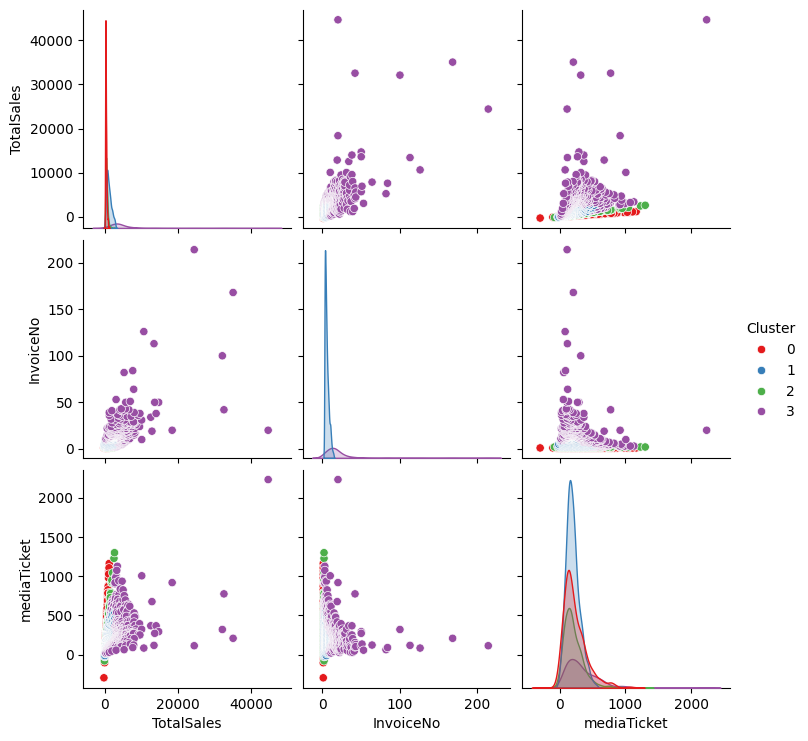

In [ ]:
camposUsar = df_to_use[['TotalSales', 'InvoiceNo', 'mediaTicket']]


# Escalar los datos (opcional pero recomendable para GMM)
scaler = StandardScaler()
camposUsar_scaled = scaler.fit_transform(camposUsar)


# Aplicar Gaussian Mixture Model (GMM)
gmm = GaussianMixture(n_components=4, random_state=42)
df_to_use["Cluster"] = gmm.fit_predict(camposUsar_scaled)  # Añadimos al df la predicción, nº cluster de cada punto

# Visualización de los clusters obtenidos
sns.pairplot(df_to_use, hue="Cluster", vars=['TotalSales', 'InvoiceNo', 'mediaTicket'], palette='Set1')
plt.show()


In [ ]:
# Ver las primeras filas del DataFrame con los clusters asignados
print(df_to_use.head())

# Si deseas calcular la puntuación de Silhouette para evaluar la calidad de los clusters
silhouette_avg = silhouette_score(camposUsar_scaled, df_to_use["Cluster"])
print(f"Puntuación de Silhouette: {silhouette_avg}")

      CustomerID  TotalSales  InvoiceNo  mediaTicket  Cluster
3015     17117.0      116.20          1       116.20        0
3012     17111.0      231.61          1       231.61        0
3011     17110.0      163.30          1       163.30        0
3007     17102.0       25.50          1        25.50        0
46       12881.0      103.00          1       103.00        0
Puntuación de Silhouette: 0.05043589057532933
